# Synthetic Data Quality Evaluation

This notebook evaluates the quality of CTGAN-generated synthetic CFO investment data by comparing it against the real dataset using multiple evaluation criteria:

- **Statistical Similarity**: Compare distributions, means, and standard deviations
- **Categorical Fidelity**: Measure how well category distributions are preserved
- **Correlation Preservation**: Check if feature relationships are maintained
- **Detection Score**: Test if a classifier can distinguish real from synthetic data (lower is better)

## 1. Import Required Libraries

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Add src directory to path for config imports
sys.path.insert(0, str(Path.cwd() / 'src'))

from config import (
    CATEGORICAL_COLUMNS,
    DATA_PATH,
    IDENTIFIER_COLUMNS,
    INTEGER_COLUMNS,
    NUMERIC_COLUMNS,
    QUALITY_REPORT_PATH,
    SEED,
    SYNTHETIC_OUTPUT_PATH,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Datasets

In [2]:
# Load real and synthetic datasets
real_df = pd.read_csv(DATA_PATH)
synthetic_df = pd.read_csv(SYNTHETIC_OUTPUT_PATH)

print("Real Dataset:")
print(f"  Shape: {real_df.shape}")
print(f"  Columns: {list(real_df.columns)}\n")

print("Synthetic Dataset:")
print(f"  Shape: {synthetic_df.shape}")
print(f"  Columns: {list(synthetic_df.columns)}\n")

# Display first few rows
print("Real Data Sample:")
display(real_df.head())

print("\nSynthetic Data Sample:")
display(synthetic_df.head())

Real Dataset:
  Shape: (11385, 21)
  Columns: ['user-id', 'user-age', 'user-gender', 'user-nationality', 'user-knowledge', 'user-loyalty', 'user-loan', 'user-income', 'user-savings', 'user-properties', 'user-riskAversion', 'user-marital', 'user-dependents', 'user-pension', 'product-type', 'product-risk', 'product-term', 'product-yield', 'transaction-id', 'year', 'month']

Synthetic Dataset:
  Shape: (11000, 21)
  Columns: ['user-id', 'user-age', 'user-gender', 'user-nationality', 'user-knowledge', 'user-loyalty', 'user-loan', 'user-income', 'user-savings', 'user-properties', 'user-riskAversion', 'user-marital', 'user-dependents', 'user-pension', 'product-type', 'product-risk', 'product-term', 'product-yield', 'transaction-id', 'year', 'month']

Real Data Sample:


,user-id,user-age,user-gender,user-nationality,user-knowledge,user-loyalty,user-loan,user-income,user-savings,user-properties,...,user-marital,user-dependents,user-pension,product-type,product-risk,product-term,product-yield,transaction-id,year,month
0,ID500,41,female,local,low,sporadic,no,10822,132392,0,...,married,0,483040,bond,medium,30,medium,T5000,2019,9
1,ID500,41,female,local,low,sporadic,no,10822,132392,0,...,married,0,483040,stock,high,10,high,T5001,2019,10
2,ID500,41,female,local,low,sporadic,no,10822,132392,0,...,married,0,483040,etf,high,10,high,T5002,2019,9
3,ID500,41,female,local,low,sporadic,no,10822,132392,0,...,married,0,483040,etf,low,20,low,T5003,2017,12
4,ID501,25,male,local,low,new,no,5284,51806,0,...,single,5,113300,etf,low,1,low,T5004,2019,10



Synthetic Data Sample:


,user-id,user-age,user-gender,user-nationality,user-knowledge,user-loyalty,user-loan,user-income,user-savings,user-properties,...,user-marital,user-dependents,user-pension,product-type,product-risk,product-term,product-yield,transaction-id,year,month
0,ID3882,47,female,foreign,low,new,no,13738,236680,2,...,divorced,0,7654483,bond,low,10,medium,T00000,2018,9
1,ID580,30,female,foreign,low,new,no,4962,25526,1,...,single,0,115224,etf,low,10,low,T00001,2018,8
2,ID3593,48,male,foreign,high,new,yes,11148,92125,5,...,single,1,3723958,etf,high,30,low,T00002,2019,8
3,ID4933,23,male,local,high,long-term,yes,11699,163051,5,...,divorced,6,415625,stock,medium,5,medium,T00003,2016,1
4,ID1800,45,male,local,low,new,no,14052,97924,7,...,divorced,0,3699954,etf,low,10,medium,T00004,2018,7


## 3. Schema Validation & Alignment

In [3]:
# Align columns and enforce schema
def align_columns(real_df, synthetic_df):
    missing = [col for col in real_df.columns if col not in synthetic_df.columns]
    for column in missing:
        synthetic_df[column] = np.nan
    return synthetic_df[real_df.columns]

def enforce_schema(df, reference):
    df = df.copy()
    for column in NUMERIC_COLUMNS:
        if column in df.columns:
            median = reference[column].median()
            df[column] = pd.to_numeric(df[column], errors="coerce").fillna(median)
    for column in INTEGER_COLUMNS:
        if column in df.columns:
            median = int(round(reference[column].median()))
            df[column] = pd.to_numeric(df[column], errors="coerce").fillna(median).round().astype(int)
    for column in CATEGORICAL_COLUMNS:
        if column in df.columns:
            fallback = reference[column].mode(dropna=True)
            fallback_value = fallback.iloc[0] if not fallback.empty else "unknown"
            df[column] = df[column].fillna(fallback_value).astype(str)
    return df

synthetic_df = align_columns(real_df, synthetic_df)
synthetic_df = enforce_schema(synthetic_df, real_df)

print("✓ Schema validated and aligned")
print(f"  Numeric columns: {len(NUMERIC_COLUMNS)}")
print(f"  Categorical columns: {len(CATEGORICAL_COLUMNS)}")
print(f"  Identifier columns: {len(IDENTIFIER_COLUMNS)}")

✓ Schema validated and aligned
  Numeric columns: 9
  Categorical columns: 10
  Identifier columns: 2


## 4. Evaluation Criteria

### 4.1 Numeric Column Statistical Comparison

In [4]:
# Calculate numeric statistics
numeric_stats = []
for column in NUMERIC_COLUMNS:
    real_vals = real_df[column].astype(float)
    synth_vals = synthetic_df[column].astype(float)
    
    numeric_stats.append({
        'Column': column,
        'Real Mean': f"{real_vals.mean():.2f}",
        'Synthetic Mean': f"{synth_vals.mean():.2f}",
        'Mean Diff': f"{abs(real_vals.mean() - synth_vals.mean()):.2f}",
        'Real Std': f"{real_vals.std():.2f}",
        'Synthetic Std': f"{synth_vals.std():.2f}",
        'Std Diff': f"{abs(real_vals.std() - synth_vals.std()):.2f}",
    })

numeric_comparison = pd.DataFrame(numeric_stats)
display(numeric_comparison)

,Column,Real Mean,Synthetic Mean,Mean Diff,Real Std,Synthetic Std,Std Diff
0,user-age,39.89,39.09,0.80,9.53,8.57,0.96
1,user-income,10549.26,10044.68,504.59,3841.96,4051.18,209.22
2,user-savings,105515.19,111371.95,5856.76,51679.40,57590.35,5910.95
3,user-properties,1.45,1.23,0.23,1.59,1.77,0.18
4,user-dependents,0.78,0.56,0.22,1.43,1.38,0.05
5,user-pension,2421530.52,2830169.70,408639.17,2554458.27,2803452.86,248994.59
6,product-term,11.70,12.27,0.57,9.88,9.10,0.78
7,year,2017.36,2017.54,0.18,1.20,1.11,0.10
8,month,6.09,6.13,0.04,3.36,3.29,0.07


### 4.2 Categorical Distribution Analysis

In [5]:
# Calculate categorical metrics
categorical_stats = []
for column in CATEGORICAL_COLUMNS:
    real_counts = real_df[column].value_counts(normalize=True, dropna=False)
    synth_counts = synthetic_df[column].value_counts(normalize=True, dropna=False)
    
    categories = sorted(set(real_counts.index).union(synth_counts.index))
    real_vec = real_counts.reindex(categories, fill_value=0.0)
    synth_vec = synth_counts.reindex(categories, fill_value=0.0)
    
    # Total Variation Distance
    tvd = float(np.abs(real_vec - synth_vec).sum() / 2.0)
    
    categorical_stats.append({
        'Column': column,
        'Total Variation Distance': f"{tvd:.4f}",
        'Top Real Category': real_counts.idxmax() if not real_counts.empty else None,
        'Top Synthetic Category': synth_counts.idxmax() if not synth_counts.empty else None,
    })

categorical_comparison = pd.DataFrame(categorical_stats)
display(categorical_comparison)

,Column,Total Variation Distance,Top Real Category,Top Synthetic Category
0,user-gender,0.1482,male,female
1,user-nationality,0.0151,local,local
2,user-knowledge,0.0450,low,low
3,user-loyalty,0.0169,new,new
4,user-loan,0.0700,no,no
5,user-riskAversion,0.0160,low,low
6,user-marital,0.0778,married,single
7,product-type,0.1019,etf,etf
8,product-risk,0.0614,high,high
9,product-yield,0.0304,high,high


### 4.3 Correlation Preservation

#### Correlation Calculation Formula

For each pair of numeric columns $(X, Y)$, the Pearson correlation coefficient is:

$$r_{X,Y} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

where:
- $x_i, y_i$ are individual data points
- $\bar{x}, \bar{y}$ are the means
- $r \in [-1, 1]$: **+1** = perfect positive correlation, **0** = no linear relationship, **-1** = perfect negative correlation

#### Correlation Shift Metric

The correlation shift measures how well synthetic data preserves feature relationships:

$$\text{Correlation Shift} = \frac{1}{n^2} \sum_{i,j} |r^{\text{synth}}_{i,j} - r^{\text{real}}_{i,j}|$$

This computes the **mean absolute difference** across all pairwise correlations in the correlation matrices.

#### Evaluation Criteria

| Correlation Shift | Quality Rating | Interpretation |
|-------------------|----------------|----------------|
| **< 0.05** | ✓ Excellent | Relationships almost perfectly preserved |
| **0.05 - 0.10** | ✓ Good | Minor deviations, acceptable for most use cases |
| **0.10 - 0.20** | ⚠ Fair | Noticeable differences, may impact ML models |
| **> 0.20** | ✗ Poor | Major distortions, synthetic data lost key patterns |

#### Why Lower is Better

**Goal**: Synthetic data should maintain the same statistical relationships between features as real data.

**Example**: If real data shows strong correlation between `income` and `savings` ($r = 0.82$), but synthetic shows weak correlation ($r = 0.55$), the absolute difference is **0.27** — indicating poor quality.

**Impact of High Correlation Shift**:
- ML models trained on synthetic data won't learn correct feature interactions
- Business rules based on feature relationships will fail
- Predictive analytics accuracy degrades
- Data augmentation provides misleading patterns

In [6]:
# Calculate correlation shift
real_corr = real_df[NUMERIC_COLUMNS].corr().fillna(0.0)
synth_corr = synthetic_df[NUMERIC_COLUMNS].corr().fillna(0.0)
corr_shift = float(np.abs(real_corr - synth_corr).values.mean())

print(f"Mean Absolute Correlation Shift: {corr_shift:.4f}")
print("  → Lower is better (0 = perfect correlation preservation)")

Mean Absolute Correlation Shift: 0.0634
  → Lower is better (0 = perfect correlation preservation)


### 4.4 Machine Learning Detection Score

In [7]:
# Train a classifier to distinguish real from synthetic data
feature_df = pd.concat([
    real_df.assign(__is_real__=1),
    synthetic_df.assign(__is_real__=0),
])

y = feature_df.pop("__is_real__")
feature_df = feature_df.drop(columns=IDENTIFIER_COLUMNS, errors="ignore")
feature_df = pd.get_dummies(feature_df, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, y, test_size=0.3, stratify=y, random_state=SEED
)

model = LogisticRegression(max_iter=1000, random_state=SEED)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
detection_score = 2 * (auc - 0.5)

print(f"Detection AUC: {auc:.4f}")
print(f"Detection Score: {detection_score:.4f}")
print("\n  → AUC = 0.5 means perfect synthetic data (indistinguishable)")
print("  → AUC = 1.0 means easily detectable (poor quality)")
print(f"\nInterpretation: {'✓ Good' if detection_score < 0.1 else '⚠ Needs improvement' if detection_score < 0.3 else '✗ Poor'}")

Detection AUC: 0.6717
Detection Score: 0.3433

  → AUC = 0.5 means perfect synthetic data (indistinguishable)
  → AUC = 1.0 means easily detectable (poor quality)

Interpretation: ✗ Poor


/Users/snehasrikanth/synth-data-cfo/synthetic-data/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Visualizations

### 5.1 Numeric Distribution Comparison

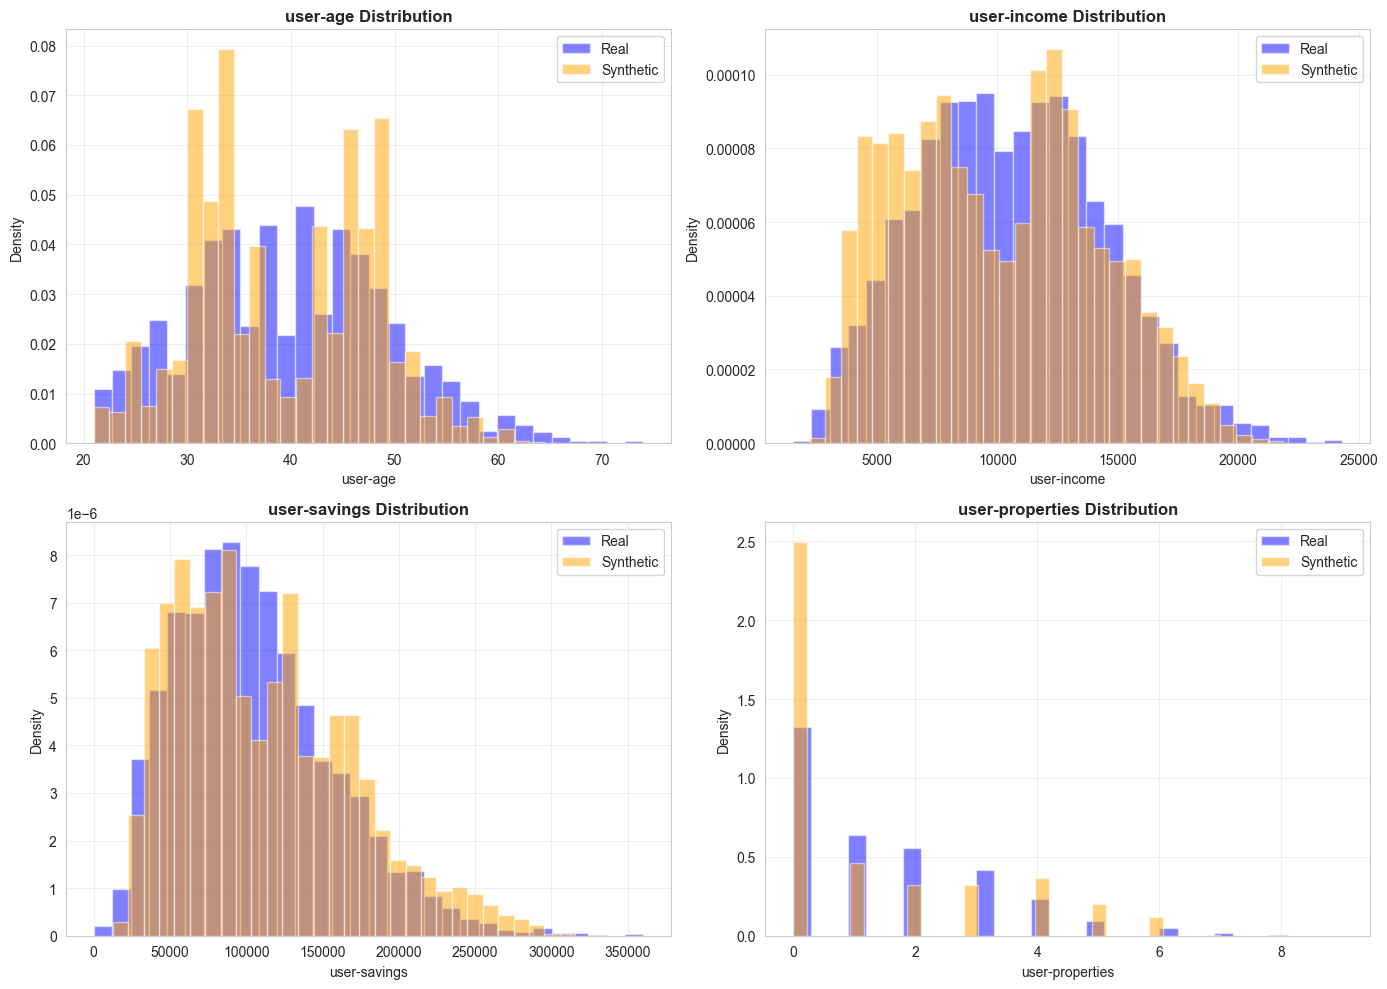

In [8]:
# Plot distributions for selected numeric columns
sample_numeric_cols = NUMERIC_COLUMNS[:4]  # Show first 4 columns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, column in enumerate(sample_numeric_cols):
    ax = axes[idx]
    
    # Histograms
    ax.hist(real_df[column], bins=30, alpha=0.5, label='Real', color='blue', density=True)
    ax.hist(synthetic_df[column], bins=30, alpha=0.5, label='Synthetic', color='orange', density=True)
    
    ax.set_title(f'{column} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Categorical Distribution Comparison

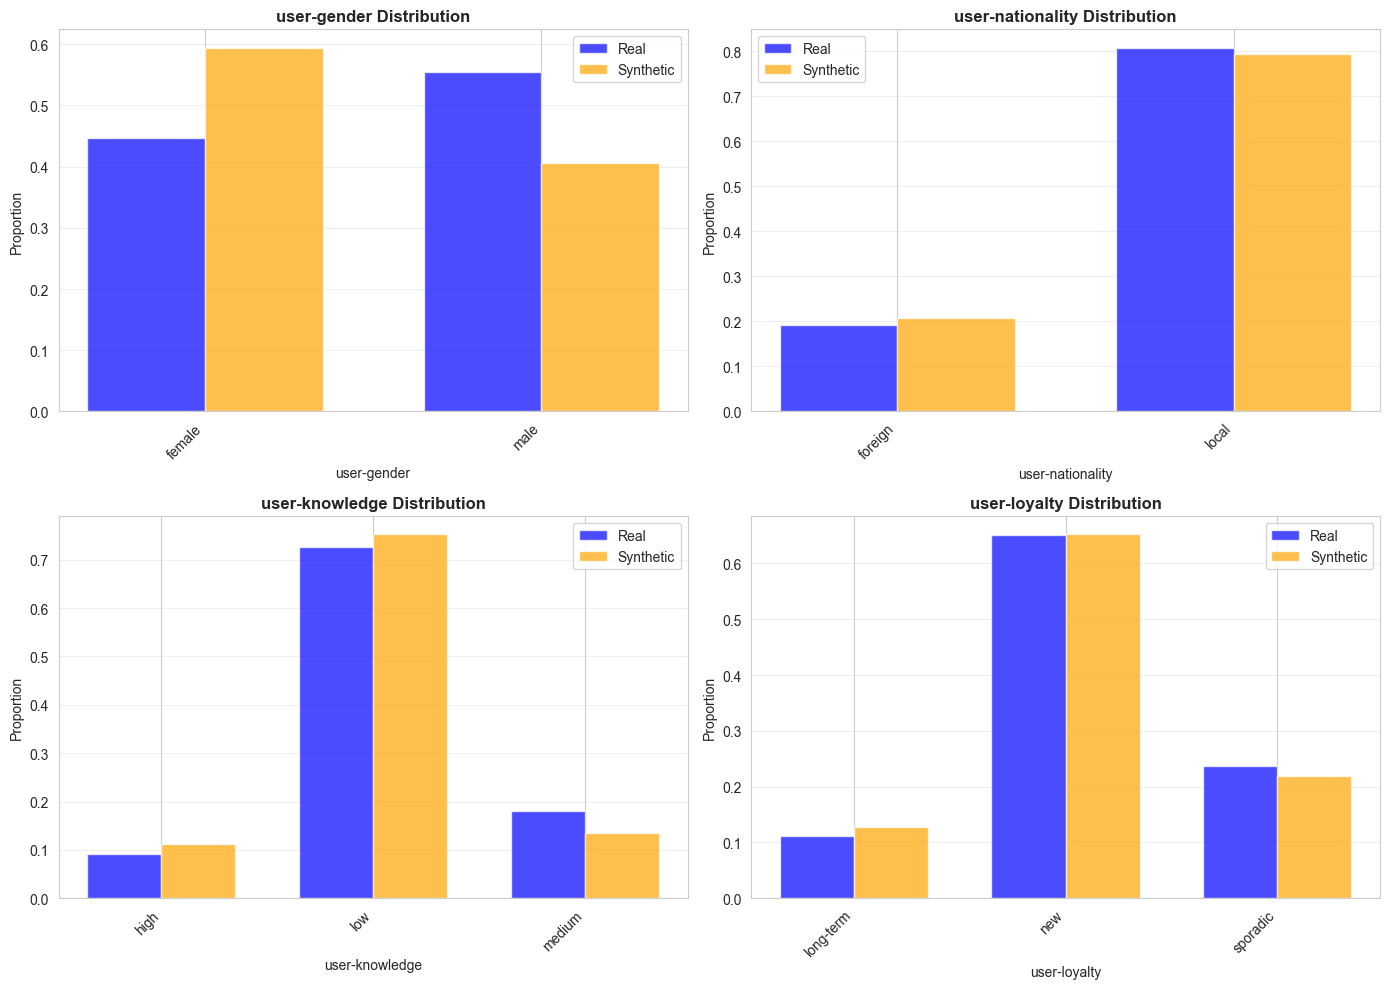

In [9]:
# Plot categorical distributions
sample_categorical_cols = CATEGORICAL_COLUMNS[:4]  # Show first 4 columns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, column in enumerate(sample_categorical_cols):
    ax = axes[idx]
    
    # Get value counts
    real_counts = real_df[column].value_counts(normalize=True).sort_index()
    synth_counts = synthetic_df[column].value_counts(normalize=True).sort_index()
    
    # Combine categories
    all_categories = sorted(set(real_counts.index).union(synth_counts.index))
    real_vals = [real_counts.get(cat, 0) for cat in all_categories]
    synth_vals = [synth_counts.get(cat, 0) for cat in all_categories]
    
    x = np.arange(len(all_categories))
    width = 0.35
    
    ax.bar(x - width/2, real_vals, width, label='Real', color='blue', alpha=0.7)
    ax.bar(x + width/2, synth_vals, width, label='Synthetic', color='orange', alpha=0.7)
    
    ax.set_title(f'{column} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(column)
    ax.set_ylabel('Proportion')
    ax.set_xticks(x)
    ax.set_xticklabels(all_categories, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.3 Correlation Heatmaps

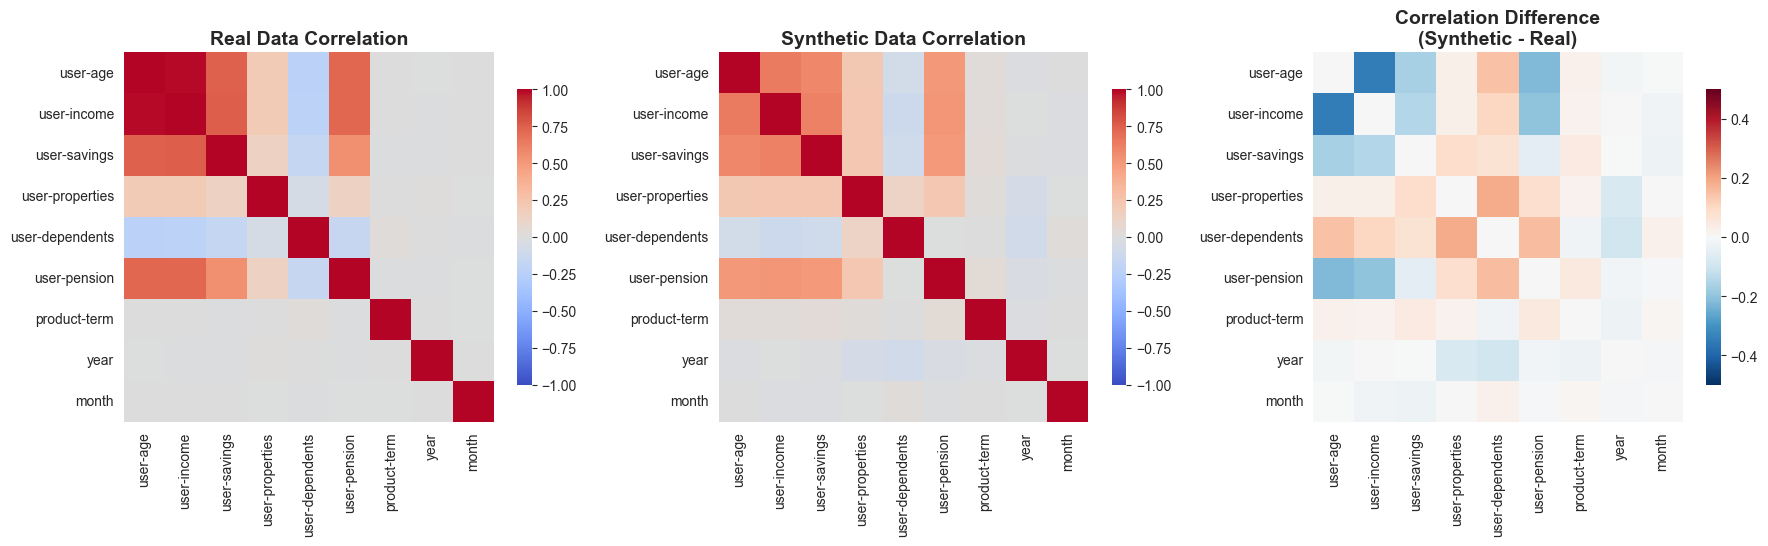

Mean Absolute Correlation Error: 0.0634


In [10]:
# Correlation comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real data correlation
sns.heatmap(real_corr, ax=axes[0], cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Real Data Correlation', fontsize=14, fontweight='bold')

# Synthetic data correlation
sns.heatmap(synth_corr, ax=axes[1], cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Synthetic Data Correlation', fontsize=14, fontweight='bold')

# Difference
corr_diff = synth_corr - real_corr
sns.heatmap(corr_diff, ax=axes[2], cmap='RdBu_r', center=0, 
            vmin=-0.5, vmax=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[2].set_title('Correlation Difference\n(Synthetic - Real)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Mean Absolute Correlation Error: {np.abs(corr_diff).values.mean():.4f}")

## 6. Summary Report

In [11]:
# Generate comprehensive quality report
report = {
    "dataset_info": {
        "num_rows_real": len(real_df),
        "num_rows_synthetic": len(synthetic_df),
        "num_numeric_columns": len(NUMERIC_COLUMNS),
        "num_categorical_columns": len(CATEGORICAL_COLUMNS),
    },
    "numeric_statistics": numeric_comparison.to_dict('records'),
    "categorical_statistics": categorical_comparison.to_dict('records'),
    "correlation_shift": corr_shift,
    "detection": {
        "auc": auc,
        "detection_score": detection_score,
    }
}

# Save report
QUALITY_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
with QUALITY_REPORT_PATH.open("w") as f:
    json.dump(report, f, indent=2)

print("=" * 60)
print("SYNTHETIC DATA QUALITY SUMMARY")
print("=" * 60)
print(f"\n📊 Dataset Size:")
print(f"  Real: {len(real_df):,} rows")
print(f"  Synthetic: {len(synthetic_df):,} rows")
print(f"\n📈 Correlation Preservation:")
print(f"  Mean Absolute Shift: {corr_shift:.4f} {'✓' if corr_shift < 0.1 else '⚠'}")
print(f"\n🎯 Detection Score:")
print(f"  AUC: {auc:.4f}")
print(f"  Detection Score: {detection_score:.4f} {'✓' if detection_score < 0.1 else '⚠' if detection_score < 0.3 else '✗'}")
print(f"\n💾 Report saved to: {QUALITY_REPORT_PATH}")
print("=" * 60)

SYNTHETIC DATA QUALITY SUMMARY

📊 Dataset Size:
  Real: 11,385 rows
  Synthetic: 11,000 rows

📈 Correlation Preservation:
  Mean Absolute Shift: 0.0634 ✓

🎯 Detection Score:
  AUC: 0.6717
  Detection Score: 0.3433 ✗

💾 Report saved to: /Users/snehasrikanth/synth-data-cfo/synthetic-data/artifacts/quality_report.json
